In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


In [3]:
# Load your dataset
data = pd.read_csv("augmented_hand_landmarks.csv")

# Extract features (landmark coordinates) and labels
X = data.drop(columns=['label']).values  # Only coordinates
y = data['label'].values  # Labels

# Generate pairs (This example assumes binary labels for simplicity, modify as per your dataset)

def create_pairs(X, y):
    pairs = []
    labels = []
    unique_labels = np.unique(y)
    label_to_indices = {label: np.where(y == label)[0] for label in unique_labels}
    
    for label in unique_labels:
        indices = label_to_indices[label]
        num_indices = len(indices)
        
        # Positive pairs
        for i in range(num_indices):
            # Randomly select another sample from the same class
            j = np.random.choice(indices)
            pairs.append([X[indices[i]], X[j]])
            labels.append(1)  # Similar pair
        
        # Negative pairs
        for i in range(num_indices):
            # Select a different label
            different_label = np.random.choice(unique_labels[unique_labels != label])
            neg_index = np.random.choice(label_to_indices[different_label])
            pairs.append([X[indices[i]], X[neg_index]])
            labels.append(0)  # Dissimilar pair
    
    return np.array(pairs), np.array(labels)

pairs, labels = create_pairs(X, y)
pairs_train, pairs_test, labels_train, labels_test = train_test_split(pairs, labels, test_size=0.2, random_state=42)


In [4]:
from tensorflow.keras import layers, Model

def build_base_network(input_shape):
    input = layers.Input(shape=input_shape)
    
    # First dense layer with increased width
    x = layers.Dense(256, activation=None, kernel_initializer='he_normal')(input)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)  # Apply ReLU after Batch Normalization
   
    # Second dense layer
    x = layers.Dense(128, activation=None, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Third dense layer
    x = layers.Dense(128, activation=None, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Fourth dense layer
    x = layers.Dense(64, activation=None, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Fifth dense layer
    x = layers.Dense(256, activation=None, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Final embedding layer with 128 dimensions (no activation)
    x = layers.Dense(128, activation=None)(x)
    
    return Model(input, x)

input_shape = pairs_train.shape[2:]

base_network = build_base_network(input_shape)

# Inputs for the pairs
input_a = layers.Input(shape=input_shape)
input_b = layers.Input(shape=input_shape)

# Generate the embeddings for each input
embedding_a = base_network(input_a)
embedding_b = base_network(input_b)

# Compute the L2 distance between embeddings
distance = layers.Lambda(lambda embeddings: tf.reduce_sum(tf.square(embeddings[0] - embeddings[1]), axis=-1))([embedding_a, embedding_b])

# Siamese Network model
siamese_model = Model(inputs=[input_a, input_b], outputs=distance)


In [5]:
# Contrastive loss
def contrastive_loss(y_true, y_pred, margin=1.0):
    y_true = tf.cast(y_true, y_pred.dtype)
    positive_loss = y_true * tf.square(y_pred)
    negative_loss = (1 - y_true) * tf.square(tf.maximum(margin - y_pred, 0))
    return tf.reduce_mean(positive_loss + negative_loss)

# Custom accuracy
def accuracy(y_true, y_pred, threshold=1.0):
    print(f"{y_pred} < {threshold}")
    y_pred_labels = tf.cast(y_pred < threshold, tf.float32)
    return tf.reduce_mean(tf.cast(tf.equal(y_true, y_pred_labels), tf.float32))

siamese_model.compile(optimizer='adam', loss=contrastive_loss, metrics=[accuracy])


In [6]:
history = siamese_model.fit(
    [pairs_train[:, 0], pairs_train[:, 1]], labels_train,
    validation_data=([pairs_test[:, 0], pairs_test[:, 1]], labels_test),
    batch_size=256,
    epochs=100
)

Epoch 1/100
Tensor("model_1/lambda/Sum:0", shape=(None,), dtype=float32) < 1.0
Tensor("model_1/lambda/Sum:0", shape=(None,), dtype=float32) < 1.0
4574/4574 [==============================] - 78s 17ms/step - loss: 6.8804 - accuracy: 0.7842 - val_loss: 0.0626 - val_accuracy: 0.8342
Epoch 2/100
4574/4574 [==============================] - 75s 16ms/step - loss: 0.0482 - accuracy: 0.8766 - val_loss: 0.0228 - val_accuracy: 0.9175
Epoch 3/100
4574/4574 [==============================] - 75s 16ms/step - loss: 0.0179 - accuracy: 0.9371 - val_loss: 0.0070 - val_accuracy: 0.9652
Epoch 4/100
4574/4574 [==============================] - 74s 16ms/step - loss: 0.0071 - accuracy: 0.9698 - val_loss: 0.0035 - val_accuracy: 0.9786
Epoch 5/100
4574/4574 [==============================] - 75s 16ms/step - loss: 0.0023 - accuracy: 0.9859 - val_loss: 6.8739e-04 - val_accuracy: 0.9974
Epoch 6/100
4574/4574 [==============================] - 75s 16ms/step - loss: 0.0013 - accuracy: 0.9914 - val_loss: 4.2773e-04

In [7]:
# Evaluate on test data
test_loss, test_acc = siamese_model.evaluate([pairs_test[:, 0], pairs_test[:, 1]], labels_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

9147/9147 [==============================] - 44s 5ms/step - loss: 3.7203e-06 - accuracy: 0.9999
Test Loss: 0.0000, Test Accuracy: 0.9999


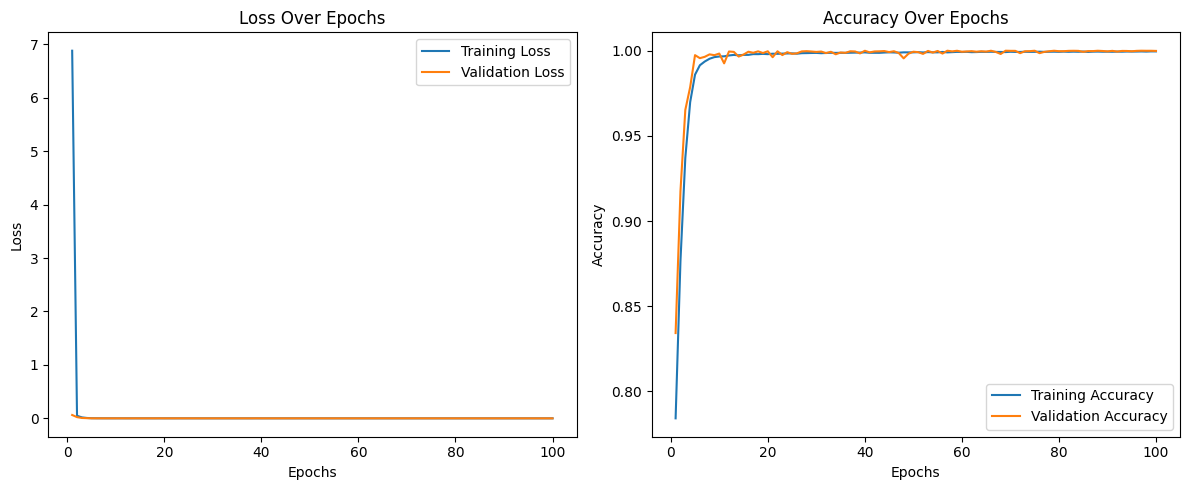

In [8]:
# Plot training/validation loss and accuracy
def plot_history(history):
    epochs = range(1, len(history.history['loss']) + 1)
    
    # Loss plot
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss')
    plt.plot(epochs, history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy')
    plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)

In [9]:
base_network.save("embedding_model_aug_contrastive.h5")
print("Base embedding model saved as embedding_model_aug_contrastive.h5")

Base embedding model saved as embedding_model_aug_contrastive.h5


In [10]:
import json
import numpy as np

def compute_class_means(model, X, y, classes):
    """Compute mean embeddings for each class."""
    class_means = {}
    for cls in classes:
        indices = np.where(y == cls)[0]
        embeddings = model.predict(X[indices])
        class_means[cls] = np.mean(embeddings, axis=0).tolist()
    
    # Save class means to a JSON file
    with open("class_means_aug.json", "w") as f:
        json.dump(class_means, f)
    print("Class means saved to class_means_aug.json")

# Assuming X and y are your dataset and labels
classes = np.unique(y)
compute_class_means(base_network, X, y, classes)


802/802 [==============================] - 2s 2ms/step
Class means saved to class_means_aug.json
